# Theta_reg analysis — rare vs typical events

Same setup as `turb_theta_reg_all.ipynb` (only `Theta_reg`, mean +- std across seeds), but every real-data analysis is split by a rare/typical classification of the whole `x1` dataset (not the 350 hand-picked `selected_samples.pt` events).

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import sys, os, re, math
from types import SimpleNamespace

root = Path().resolve()
sys.path.insert(0, str(root / '../codes'))
from sde_routines import *
from utils import *
from utils_experiment import *
from filters_bank import *
from potentials import *
from ortho_wavelet import *
from check_potentials import *  # theta_column_map, decode_mod2_stq, etc.

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|', root)

device: cuda | /libre/zelcoc/MGD-for-Maximum-Entropy-Generation/turbulence


In [23]:
import os

# LOCAL vs JEAN ZAY -- load_turbulence_1d()'s default path in data_loader.py
# is Jean-Zay-only (/lustre/...). Flip to "jean_zay" there instead of editing this.
# PHI_CHUNK_SIZE batches phi(x)/grad(x) evaluation over the sample dim -- evaluating
# Scattering_Fourth_Order_Mod2_{Real,Imag}_Q1 on the full n1=5000 batch at once
# materializes a ~5.9GB intermediate BEFORE any reduction (measured directly:
# DefaultCPUAllocator asked for exactly 5898240000 bytes) -- chunking avoids it
# with no change to the result. Jean Zay has enough RAM/GPU memory to skip it.
RUN_LOCATION = "local"   # "local" or "jean_zay"

if RUN_LOCATION == "local" and torch.cuda.is_available():
    # A fixed chunk_size=500 assumes a GPU mostly to ourselves. On a GPU shared with
    # other processes (measured here: a co-tenant job holding ~19.5/22GB, leaving as
    # little as ~40MB free) that assumption breaks and 500 alone can still OOM. The
    # ~5.9GB/5000-sample intermediate above scales to ~1.2MiB/sample, so size the
    # chunk from what's ACTUALLY free right now (measured before potentials/data are
    # loaded, so this slightly overestimates later headroom -- the 2x margin covers
    # that plus the other job's usage not being static).
    free_bytes, _ = torch.cuda.mem_get_info()
    BYTES_PER_SAMPLE = 1.2 * 1024 ** 2
    PHI_CHUNK_SIZE = max(1, int(free_bytes / BYTES_PER_SAMPLE / 2))
    print(f"GPU free memory: {free_bytes / 1e6:.0f}MB -> PHI_CHUNK_SIZE = {PHI_CHUNK_SIZE}")
else:
    PHI_CHUNK_SIZE = 500 if RUN_LOCATION == "local" else None

if RUN_LOCATION == "local":
    local_turbulence_path = (root / "../data/data_files/turbulence_1d_period.pt").resolve()
    if local_turbulence_path.exists():
        os.environ["TURBULENCE_1D_DATA_PATH"] = str(local_turbulence_path)
    else:
        print(f"WARNING: {local_turbulence_path} not found -- load_turbulence_1d() "
              f"will fall back to its Jean Zay default path and fail locally.")
print(f"RUN_LOCATION = {RUN_LOCATION!r}, PHI_CHUNK_SIZE = {PHI_CHUNK_SIZE!r}")

GPU free memory: 2531MB -> PHI_CHUNK_SIZE = 1005
RUN_LOCATION = 'local', PHI_CHUNK_SIZE = 1005


In [24]:
J, Q, M = 8, 3, 256
sigma = 3.5
nt = 40000
n1 = 5000
lam = 5e-07
regularization = 1e-2

W = DefineWavelet('Db', m=3, device=device)
Data = load_turbulence_1d().to(device)
n1_initial = 1024
Data = split_periodize_reshape(Data, n1_initial)
scales = 2   # M == 256
for j in range(scales):
    Data = W.decompose(Data)[1]

x1 = normalize(Data[:n1])
print('Data shape:', Data.shape, '| x1 shape:', x1.shape)

Data shape: torch.Size([10000, 1, 256]) | x1 shape: torch.Size([5000, 1, 256])


/libre/zelcoc/MGD-for-Maximum-Entropy-Generation/turbulence/../data/data_loader.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Data = torch.load(data_path)


In [25]:
terms = [
    "L_6",
    "L_6_psi",
    "L_2_lowpass",
    "Scattering_Fourth_Order_Mod2_Real_Q1",
    "Scattering_Fourth_Order_Mod2_Imag_Q1",
    "Scalar_psi_gaussianK",
    "Scalar_morlet_gaussianK",
]

base_args = SimpleNamespace(J=J, Q=Q, terms=terms, nt=nt, sigma=sigma,
                              interpolant='Cos', regularization=regularization,
                              lam=lam, n1=n1)

REAL_KEY = "Scattering_Fourth_Order_Mod2_Real_Q1"
IMAG_KEY = "Scattering_Fourth_Order_Mod2_Imag_Q1"
COMPLEX_NAME = "Scattering_Fourth_Order_Mod2_Q1"

potential_colors = {
    "L_6": "tab:blue",
    "L_6_psi": "tab:olive",
    "L_2_lowpass": "tab:green",
    "Scattering_Fourth_Order_Mod2_Real_Q1": "tab:red",
    "Scattering_Fourth_Order_Mod2_Imag_Q1": "tab:purple",
    "Scalar_psi_gaussianK": "tab:orange",
    "Scalar_morlet_gaussianK": "tab:cyan",
}

In [26]:
import gc

def load_potentials_for_config(resolved_config, M, J, Q, terms, root, device):
    filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
    filters_Q = return_Filters(M, J, Q, device=device)
    potentials = get_1d_potentials(terms, J, filters, Q, scalar_param=None, parallel=False,
                                     filters_Q=filters_Q, filters_Phi=filters_Phi)
    potentials_dir = Path(root) / "experiments" / resolved_config / "fitted_potentials"
    if not potentials_dir.exists():
        raise FileNotFoundError(f"No fitted_potentials dir for {resolved_config} at {potentials_dir}")
    for name, p in potentials.items():
        p.to(device)
        if not hasattr(p, "is_fitted"):
            continue
        state_path = potentials_dir / f"{name}.pt"
        if not state_path.exists():
            raise FileNotFoundError(f"[{name}] missing fitted state at {state_path}")
        own_filters = p.filters
        loaded = type(p).load_fixed_parameters(state_path, own_filters, map_location=device)
        loaded.to(device)
        potentials[name] = loaded
    return potentials

def _chunked_call(one_chunk_fn, x, chunk_size):
    """Run one_chunk_fn over x in chunks of chunk_size, halving a chunk and
    retrying if it OOMs, instead of trusting chunk_size as exact (it's only ever a
    starting guess -- see PHI_CHUNK_SIZE's cell for why).

    The retry must happen AFTER leaving the except block, not from inside it: while
    Python is still inside an `except` clause, the caught exception's traceback stays
    alive, and a live traceback pins every local variable in the frame that raised it
    -- including whatever CUDA tensor torch.fft had already allocated right before the
    allocator gave up. Recursing from inside the except (as an earlier version of this
    function did) meant those tensors were never released, so retries made memory
    usage climb instead of shrink -- measured directly: our own process's GPU memory
    grew monotonically (622MiB -> 2.7GiB) across repeated halving instead of the
    freed chunk's memory coming back, and the recursion still failed even at a single
    sample. Exiting the except block first lets gc.collect() actually reclaim them."""
    def _try(x_sub):
        try:
            return one_chunk_fn(x_sub)
        except torch.cuda.OutOfMemoryError:
            if x_sub.shape[0] <= 1:
                raise
        # Outside the except block now -- the failed attempt's traceback (and
        # whatever it was pinning) is no longer referenced from here.
        gc.collect()
        torch.cuda.empty_cache()
        mid = x_sub.shape[0] // 2
        return torch.cat([_try(x_sub[:mid]), _try(x_sub[mid:])], dim=0)

    if chunk_size is None or x.shape[0] <= chunk_size:
        return _try(x)
    chunks = []
    for i in range(0, x.shape[0], chunk_size):
        chunks.append(_try(x[i:i + chunk_size]))
        if torch.cuda.is_available():
            gc.collect()
            torch.cuda.empty_cache()
    return torch.cat(chunks, dim=0)

def compute_phi_X(potentials, x, chunk_size=PHI_CHUNK_SIZE):
    # Each chunk's result moves to CPU before the next chunk starts (see
    # compute_phi_grad_X's docstring for why -- same reasoning, phi(x) is just much
    # smaller than grad(x) so it mattered less here, but keeping both consistent).
    def _one_chunk(x_chunk):
        feats = []
        for p in potentials.values():
            feat = p(x_chunk)
            if feat.ndim == 1:
                feat = feat.unsqueeze(1)
            feats.append(feat)
        return torch.cat(feats, dim=-1).detach().cpu()
    return _chunked_call(_one_chunk, x, chunk_size)

def compute_phi_grad_X(potentials, x, chunk_size=PHI_CHUNK_SIZE):
    """Concatenate each potential's own analytic grad(x) along the coefficient axis
    -> (n, d, T): the exact object the MGD force field is built from (compare
    sde_routines.py's grad_potential = torch.cat((grad_potential, potential.grad(x)),
    dim=1)), NOT a generic autograd Jacobian -- several potentials here wrap forward()
    in torch.no_grad(), so autograd through forward() wouldn't work anyway.

    Each chunk is moved to CPU (and the CUDA cache emptied) right after it's computed,
    before the next chunk starts, and _chunked_call halves+retries any chunk that
    still OOMs -- see its docstring for why a single precomputed chunk_size can't be
    trusted on a shared GPU, and why the retry must happen outside the except block.
    Output values are unchanged; only the device changes."""
    def _one_chunk(x_chunk):
        grad_potential = None
        for p in potentials.values():
            g = p.grad(x_chunk)
            grad_potential = g if grad_potential is None else torch.cat((grad_potential, g), dim=1)
        return grad_potential.detach().cpu()
    return _chunked_call(_one_chunk, x, chunk_size)

## Load Theta_reg across seeds

`theta_t`/MGD is never loaded -- only `Theta_reg` (final time step) and each seed's fitted potentials. A seed is dropped if: it fails to load at all, `Theta_reg` is `None` (regularised fit never saved), its `fitted_potentials` are incomplete, or (guard, not expected to trigger) its feature width differs from every other seed's.

In [27]:
pattern = re.compile(
    r"^turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_(\d+)_terms2f1130a8_20260728_1232$"
)
all_folders = os.listdir(os.path.join(root, "saved_results/samples"))
seed_range = range(300, 350)

theta_reg_final_by_seed = {}   # seed_key -> (n_features,) tensor, Theta_reg[-1]
potentials_by_seed = {}
config_by_seed = {}
expected_n_features = None

for folder in sorted(all_folders):
    match = pattern.match(folder)
    if not match:
        continue
    seed_val = int(match.group(1))
    if seed_val not in seed_range:
        continue
    key = f"seed{seed_val}"
    resolved_config = folder

    loaded_data = try_load_experiment(root, resolved_config, device)
    if not (loaded_data and loaded_data.get('loaded', False)):
        print(f"  -> {key}: failed to load, skipping.")
        continue
    if loaded_data.get('Theta_reg') is None:
        print(f"  -> {key}: no Theta_reg (regularised fit never saved), skipping.")
        continue

    try:
        potentials_k = load_potentials_for_config(
            resolved_config, M, J=base_args.J, Q=base_args.Q,
            terms=base_args.terms, root=root, device=device,
        )
    except FileNotFoundError as e:
        print(f"  -> {key}: incomplete fitted_potentials, skipping: {e}")
        continue

    theta_final = loaded_data['Theta_reg'][-1].detach().cpu()
    n_features_k = theta_final.shape[-1]

    # Guard: verified empirically (all 47 loadable seeds, this sigma/config) that
    # every seed's fitted potentials produce the SAME feature width/active regions --
    # not assumed. A mismatch here would be a genuine anomaly; drop it loudly rather
    # than silently pool mismatched columns into reg_all.
    if expected_n_features is None:
        expected_n_features = n_features_k
        print(f"  -> Reference feature width set from {key}: {expected_n_features}")
    elif n_features_k != expected_n_features:
        print(f"  -> WARNING: {key} has {n_features_k} features, expected "
              f"{expected_n_features} -- fitted potentials differ from every other "
              f"seed so far, dropping this seed.")
        del loaded_data, potentials_k
        continue

    theta_reg_final_by_seed[key] = theta_final
    potentials_by_seed[key] = potentials_k
    config_by_seed[key] = resolved_config
    del loaded_data

print(f"\nLoaded {len(theta_reg_final_by_seed)} usable seeds (Theta_reg only).")

/libre/zelcoc/MGD-for-Maximum-Entropy-Generation/codes/utils.py:138: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(pt_path if pt_path.exists() else path_no

  -> Reference feature width set from seed300: 272
  -> seed316: no Theta_reg (regularised fit never saved), skipping.
  -> seed327: no Theta_reg (regularised fit never saved), skipping.
Could not load turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_330_terms2f1130a8_20260728_1232: [Errno 2] No such file or directory: '/libre/zelcoc/MGD-for-Maximum-Entropy-Generation/turbulence/saved_results/sampling_times/turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_330_terms2f1130a8_20260728_1232'
  -> seed330: failed to load, skipping.
  -> seed331: incomplete fitted_potentials, skipping: [Scalar_psi_gaussianK] missing fitted state at /libre/zelcoc/MGD-for-Maximum-Entropy-Generation/turbulence/experiments/turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_331_terms2f1130a8_20260728_1232/fitted_potentials/Scalar_psi_gaussianK.pt
Could not load turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_332_terms2f1130a8_20260728_1232: [Errno

In [28]:
seed_keys = sorted(theta_reg_final_by_seed.keys(), key=lambda s: int(s.replace("seed", "")))
reg_all = torch.stack([theta_reg_final_by_seed[k] for k in seed_keys])   # (n_seeds, n_features)
n_seeds, n_features = reg_all.shape

theta_reg_mean = reg_all.mean(0).numpy()
theta_reg_std = reg_all.std(0, correction=1).numpy()
print(f"reg_all: {tuple(reg_all.shape)}  ({n_seeds} seeds, {n_features} features)")

# Any one seed's fitted potentials for phi(x) shape/column-decoding -- functionally
# identical across every loaded seed here (verified: same active_flat for both
# Scalar_* potentials across all 47 seeds), so which one doesn't matter.
REFERENCE_SEED = seed_keys[0]
potentials_ref = potentials_by_seed[REFERENCE_SEED]
print(f"Using {REFERENCE_SEED}'s fitted potentials for phi(x) (shape/decoding only, "
      f"never as a theta source -- theta values are always reg_all.mean(0)/std(0)).")

col_map = theta_column_map(potentials_ref, n_features)
family_ranges = {name: (a, a + d) for name, (a, d) in col_map.items()}
for name, (a, b) in family_ranges.items():
    print(f"  {name:45s} [{a:4d}:{b:<4d}]  dim={b - a}")

reg_all: (43, 272)  (43 seeds, 272 features)
Using seed300's fitted potentials for phi(x) (shape/decoding only, never as a theta source -- theta values are always reg_all.mean(0)/std(0)).
  L_6                                           [   0:9   ]  dim=9
  L_6_psi                                       [   9:34  ]  dim=25
  L_2_lowpass                                   [  34:35  ]  dim=1
  Scalar_psi_gaussianK                          [  35:105 ]  dim=70
  Scalar_morlet_gaussianK                       [ 105:132 ]  dim=27
  Scattering_Fourth_Order_Mod2_Real_Q1          [ 132:216 ]  dim=84
  Scattering_Fourth_Order_Mod2_Imag_Q1          [ 216:272 ]  dim=56


## Whole-dataset rare/typical split

Verbatim classification method from `extract_samples.ipynb` (cells 9-10), applied here to `Data[:n1]` so the resulting indices line up with `x1`/`phi_X` (both length n1) -- NOT the same as reusing that notebook's own indices: it classifies raw length-256 windows (zero wavelet decompositions), while `x1` here is wavelet-decomposed down to length 256 via 2 decompositions from length-1024 windows. Same method, different signal stage, needed to keep labels aligned with this notebook's own `phi_X`.

In [69]:
def compute_acceleration(Data):
    """a(t) = Data(t+1) - Data(t), lag-1 velocity increment."""
    return Data[..., 1:] - Data[..., :-1]

def extract_rare_typical(Data, criterion='percentile', std_threshold=40,
                          sustained_sigma=10, min_exceedances=3, percentile=95):
    accel = compute_acceleration(Data)
    accel_std = accel.flatten().std(unbiased=True).item()
    B = accel.shape[0]
    reduce_dims = tuple(range(1, accel.ndim))
    per_traj_max_abs_accel = accel.abs().amax(dim=reduce_dims)

    if criterion == 'max_sigma':
        is_rare = per_traj_max_abs_accel > std_threshold * accel_std
        info = dict(accel_std=accel_std, threshold=std_threshold * accel_std)
    elif criterion == 'sustained_sigma':
        exceed_mask = accel.abs() > sustained_sigma * accel_std
        per_traj_exceed_count = exceed_mask.reshape(B, -1).sum(dim=1)
        is_rare = per_traj_exceed_count >= min_exceedances
        info = dict(accel_std=accel_std, threshold=sustained_sigma * accel_std,
                    min_exceedances=min_exceedances, exceed_counts=per_traj_exceed_count)
    elif criterion == 'percentile':
        cutoff = np.percentile(per_traj_max_abs_accel.cpu().numpy(), percentile)
        is_rare = per_traj_max_abs_accel > cutoff
        info = dict(accel_std=accel_std, percentile=percentile, cutoff=cutoff)
    else:
        raise ValueError(f"unknown criterion '{criterion}'")

    idx_rare = torch.nonzero(is_rare).flatten().tolist()
    idx_typical = torch.nonzero(~is_rare).flatten().tolist()
    return idx_typical, idx_rare, info

idx_typical, idx_rare, info_split = extract_rare_typical(Data[:n1], criterion='percentile', percentile=99.5) 
category_indices = {'typical': idx_typical, 'rare': idx_rare}
category_colors = {'typical': 'tab:blue', 'rare': 'tab:red'}
print(f"Whole dataset (n1={n1}) split: typical {len(idx_typical)}, rare {len(idx_rare)}   {info_split}")

Whole dataset (n1=5000) split: typical 4975, rare 25   {'accel_std': 0.3395721912384033, 'percentile': 99.5, 'cutoff': np.float32(6.206038)}


## Per-family energy, split by category

Same `phi_X`/`family_energy`/`total_log_p_unnorm` as the pooled notebook, just indexed by `category_indices` afterward -- the underlying $\theta^\top\varphi(x)$ computation is identical, only the grouping changes.

**Sign convention, checked not assumed:** this codebase's `theta` is fit so that
$p_\theta(x) \propto \exp(+\theta^\top\varphi(x))$ -- i.e. $\log p_\theta(x) =
\theta^\top\varphi(x) - \log Z(\theta)$, the standard Jaynes/MaxEnt exponential
family, **no built-in minus sign**. Confirmed directly from the fitting step in
`sde_routines.py` (`x_{k+1} = y_k + (\nabla\varphi)^\top\theta_k`): this is a
Langevin *ascent* step, i.e. `x` moves along $+\nabla_x(\theta^\top\varphi(x))$,
which is only a valid sampler for $p$ if $\nabla_x\log p(x) = \nabla_x(\theta^\top
\varphi(x))$.

If you want the physics-style potential $U(x)$ such that $p(x)\propto e^{-U(x)}$
(lower $U$ = more likely), that is $U(x) := -\theta^\top\varphi(x) = -\log
p_\theta(x) + \text{const.}$ -- **minus** the `family_energy`/`total_log_p_unnorm`
computed below (see `turb_theta_reg_all.ipynb` for the fuller per-coefficient U
treatment). Opposite sign convention from `codes/mala.py`'s unused `Energy` class
(`energy(x) = theta @ phi(x)`, fed into `log_pix = -energy(x)`) -- don't mix the
two without flipping a sign.

In [70]:
phi_X = compute_phi_X(potentials_ref, x1).detach().cpu().numpy()   # (n1, n_features)

# family_energy is theta.phi(x) per family, i.e. a per-family piece of log p_theta(x)
# (NOT the physics-style potential U -- see the sign-convention note above; U = -theta.phi).
family_energy = {
    name: (theta_reg_mean[a:b] * phi_X[:, a:b]).sum(axis=-1)
    for name, (a, b) in family_ranges.items()
}
total_log_p_unnorm = np.sum(np.stack(list(family_energy.values())), axis=0)

comparison = []
ranges_with_total = {**family_ranges, 'TOTAL': (0, n_features)}
for category, idx in category_indices.items():
    for name, (a, b) in ranges_with_total.items():
        sample_totals = phi_X[idx, a:b] @ theta_reg_mean[a:b]
        comparison.append({
            'category': category, 'family': name,
            'mean_total': sample_totals.mean(), 'std_total': sample_totals.std(ddof=1),
            'mean_U': -sample_totals.mean(),   # physics convention: U = -theta.phi
        })
comparison_df = pd.DataFrame(comparison)
display(comparison_df.pivot(index='family', columns='category', values=['mean_total', 'std_total', 'mean_U']))

mean_total                std_total  \
category                                    rare      typical        rare   
family                                                                      
L_2_lowpass                            17.632027    14.200465   26.569534   
L_6                                  -134.910324    -0.654260  228.712662   
L_6_psi                               -32.639992     2.719154  141.656723   
Scalar_morlet_gaussianK              -802.188599  -461.369049  206.594254   
Scalar_psi_gaussianK                  705.589539  1329.863770  504.431061   
Scattering_Fourth_Order_Mod2_Imag_Q1    4.507371     0.199011   17.784538   
Scattering_Fourth_Order_Mod2_Real_Q1  270.748383   -11.597474  619.394043   
TOTAL                                  28.738440   873.361633  689.934631   

                                                      mean_U               
category                                 typical        rare      typical  
family                                                                     
L_2_lowpass                            20.136860  -17.632027   -14.200465  
L_6                                     8.736151  134.910324     0.654260  
L_6_psi                                 9.787906   32.639992    -2.719154  
Scalar_morlet_gaussianK               193.577560  802.188599   461.369049  
Scalar_psi_gaussianK                  512.644409 -705.589539 -1329.863770  
Scattering_Fourth_Order_Mod2_Imag_Q1    3.075347   -4.507371    -0.199011  
Scattering_Fourth_Order_Mod2_Real_Q1   29.530304 -270.748383    11.597474  
TOTAL                                 707.455994  -28.738440  -873.361633

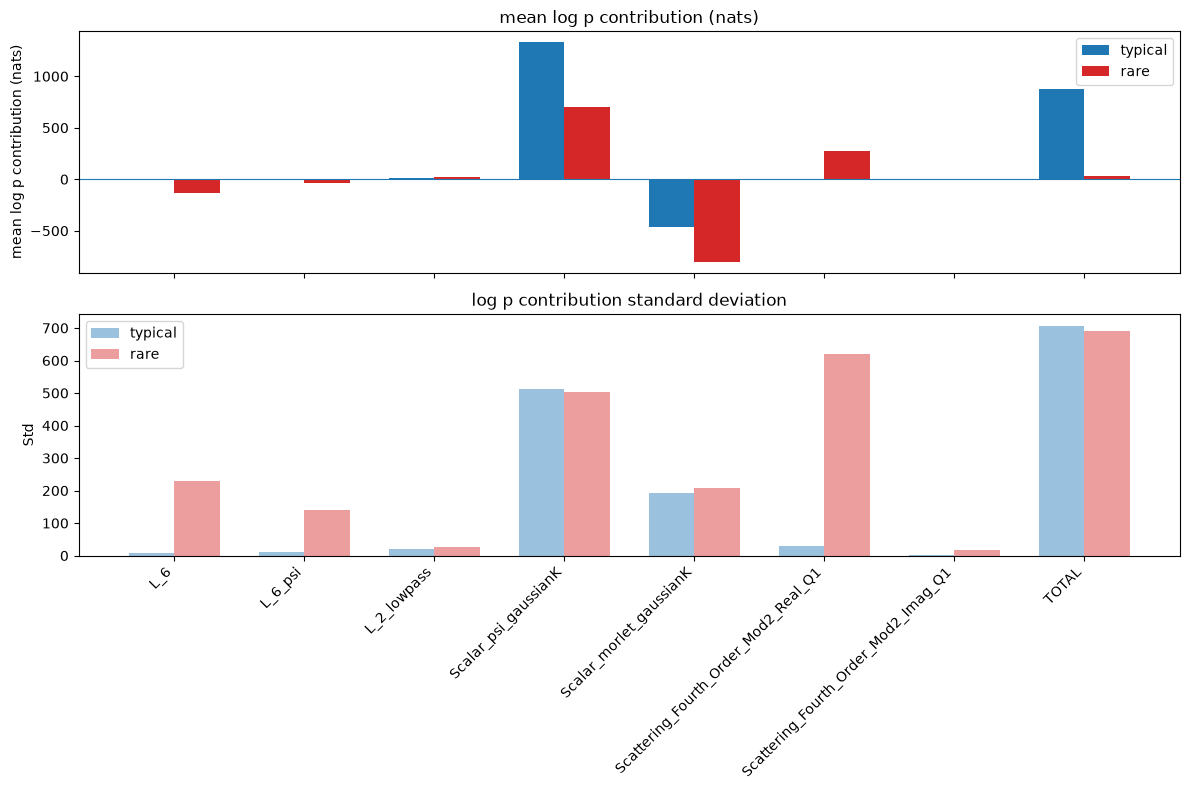

In [71]:
from matplotlib.colors import to_rgba

categories = list(category_indices.keys())

# Keep TOTAL + all families, in the desired order
family_names = list(ranges_with_total.keys())

means = {category: [] for category in categories}
stds  = {category: [] for category in categories}

for category in categories:
    idx = category_indices[category]

    for name in family_names:
        a, b = ranges_with_total[name]

        sample_totals = phi_X[idx, a:b] @ theta_reg_mean[a:b]

        means[category].append(sample_totals.mean())
        stds[category].append(sample_totals.std(ddof=1))

x = np.arange(len(family_names))
width = 0.35

# Same category colors as everywhere else in this notebook (category_colors: typical=blue, rare=red)
colors = category_colors

fig, (ax_mean, ax_std) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1]},
)
for i, category in enumerate(categories):
    offset = (-width / 2 if i == 0 else width / 2)

    ax_mean.bar(
        x + offset,
        means[category],
        width,
        label=category,
        color=colors[category],
    )

ax_mean.axhline(0, linewidth=0.8)
ax_mean.set_ylabel("mean log p contribution (nats)")
ax_mean.set_title("mean log p contribution (nats)")
ax_mean.legend()

for i, category in enumerate(categories):
    offset = (-width / 2 if i == 0 else width / 2)

    # Same color as mean, but lighter / transparent
    rgba = to_rgba(colors[category], alpha=0.45)

    ax_std.bar(
        x + offset,
        stds[category],
        width,
        label=category,
        color=rgba,
    )

ax_std.set_ylabel("Std")
ax_std.set_title("log p contribution standard deviation")
ax_std.legend()

ax_std.set_xticks(x)
ax_std.set_xticklabels(family_names, rotation=45, ha="right")

fig.tight_layout()
plt.show()

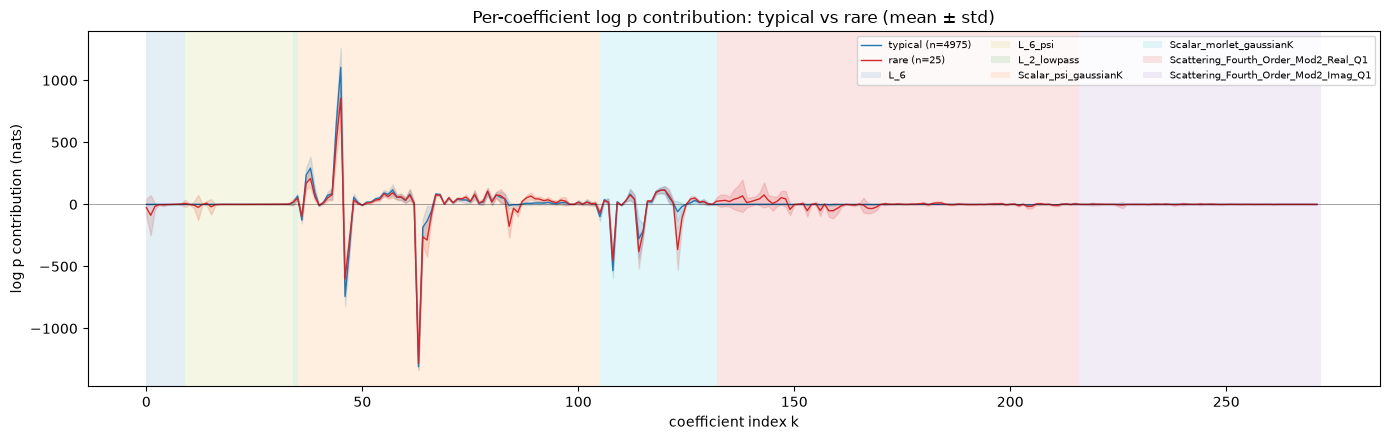

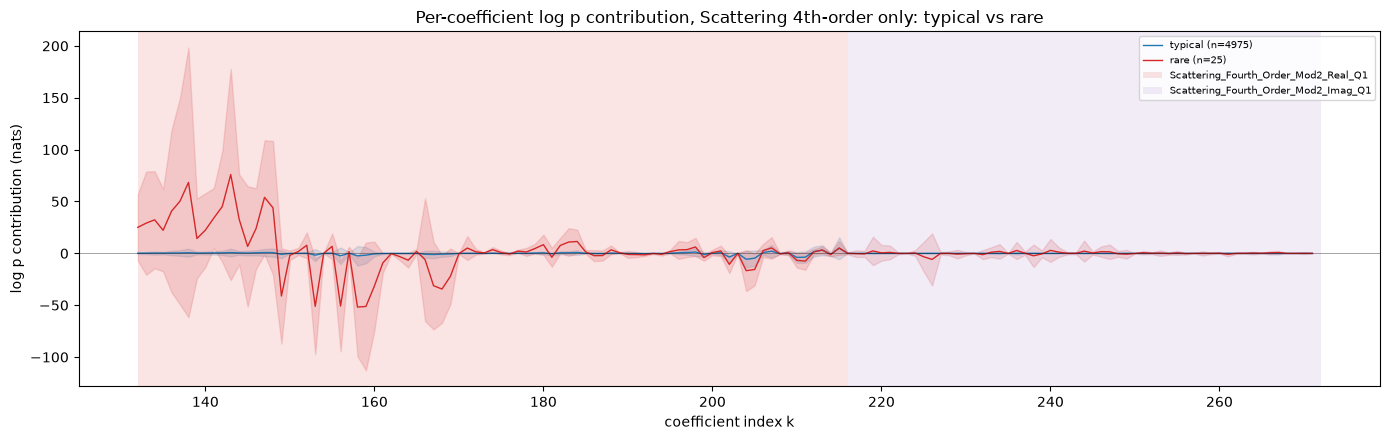

In [72]:
contrib_k = theta_reg_mean[None, :] * phi_X  # (n1, n_features) -- per-coefficient log p contribution

fig, ax = plt.subplots(figsize=(14, 4.5))
k = np.arange(n_features)
for category, idx in category_indices.items():
    mean_k = contrib_k[idx].mean(axis=0)
    std_k = contrib_k[idx].std(axis=0, ddof=1)
    color = category_colors[category]
    ax.plot(k, mean_k, color=color, lw=1, label=f'{category} (n={len(idx)})')
    ax.fill_between(k, mean_k - std_k, mean_k + std_k, color=color, alpha=0.15)

for name, (a, b) in family_ranges.items():
    ax.axvspan(a, b, color=potential_colors[name], alpha=0.12, lw=0, label=name)

ax.axhline(0, color='black', lw=0.5, alpha=0.5)
ax.set_xlabel('coefficient index k')
ax.set_ylabel('log p contribution (nats)')
ax.set_title('Per-coefficient log p contribution: typical vs rare (mean ± std)')
ax.legend(loc='upper right', fontsize=7, ncol=3)
fig.tight_layout()
plt.show()

for name, (a, b) in family_ranges.items():
    ax.axvspan(a, b, color=potential_colors[name], alpha=0.12, lw=0, label=name)

ax.axhline(0, color='black', lw=0.5, alpha=0.5)
ax.set_xlabel('coefficient index k')
ax.set_ylabel('log p contribution (nats)')
ax.set_title('Per-coefficient log p contribution: typical vs rare (mean ± std)')
ax.legend(loc='upper right', fontsize=7, ncol=3)
fig.tight_layout()
plt.show()

scatter4_families = [REAL_KEY, IMAG_KEY]
a0 = min(family_ranges[F][0] for F in scatter4_families)
b1 = max(family_ranges[F][1] for F in scatter4_families)
k4 = np.arange(a0, b1)

fig, ax = plt.subplots(figsize=(14, 4.5))
for category, idx in category_indices.items():
    mean_k = contrib_k[idx, a0:b1].mean(axis=0)
    std_k = contrib_k[idx, a0:b1].std(axis=0, ddof=1)
    color = category_colors[category]
    ax.plot(k4, mean_k, color=color, lw=1, label=f'{category} (n={len(idx)})')
    ax.fill_between(k4, mean_k - std_k, mean_k + std_k, color=color, alpha=0.15)

for name in scatter4_families:
    a, b = family_ranges[name]
    ax.axvspan(a, b, color=potential_colors[name], alpha=0.12, lw=0, label=name)

ax.axhline(0, color='black', lw=0.5, alpha=0.5)
ax.set_xlabel('coefficient index k')
ax.set_ylabel('log p contribution (nats)')
ax.set_title('Per-coefficient log p contribution, Scattering 4th-order only: typical vs rare')
ax.legend(loc='upper right', fontsize=7)
fig.tight_layout()
plt.show()

## log p, typical vs rare

$\theta^\top\varphi(x)$ = $\log p_\theta(x)$ up to the additive constant $-\log Z(\theta)$ -- the SAME constant for both categories (same $\theta$), so shape and the gap between them are exact; only the absolute axis position is unknown.

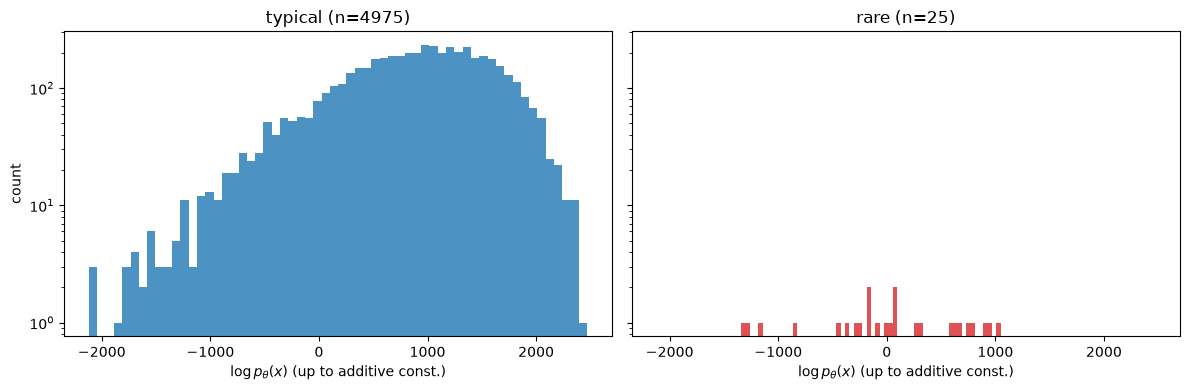

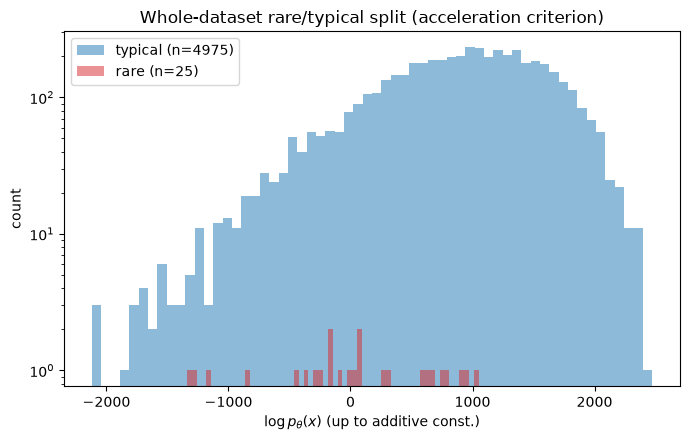

In [73]:
logp_by_category = {category: total_log_p_unnorm[idx] for category, idx in category_indices.items()}

%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for ax, (category, logp) in zip(axes, logp_by_category.items()):
    ax.hist(logp, bins=60, color=category_colors.get(category, 'tab:gray'), alpha=0.8)
    ax.set_title(f'{category} (n={len(logp)})')
    ax.set_xlabel(r'$\log p_\theta(x)$ (up to additive const.)')
    ax.set_yscale('log')
axes[0].set_ylabel('count')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
for category, logp in logp_by_category.items():
    ax.hist(logp, bins=60, color=category_colors.get(category, 'tab:gray'),
             alpha=0.5, label=f'{category} (n={len(logp)})')
ax.set_xlabel(r'$\log p_\theta(x)$ (up to additive const.)')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend()
ax.set_title('Whole-dataset rare/typical split (acceleration criterion)')
fig.tight_layout()
plt.show()

## Florentin's plot 

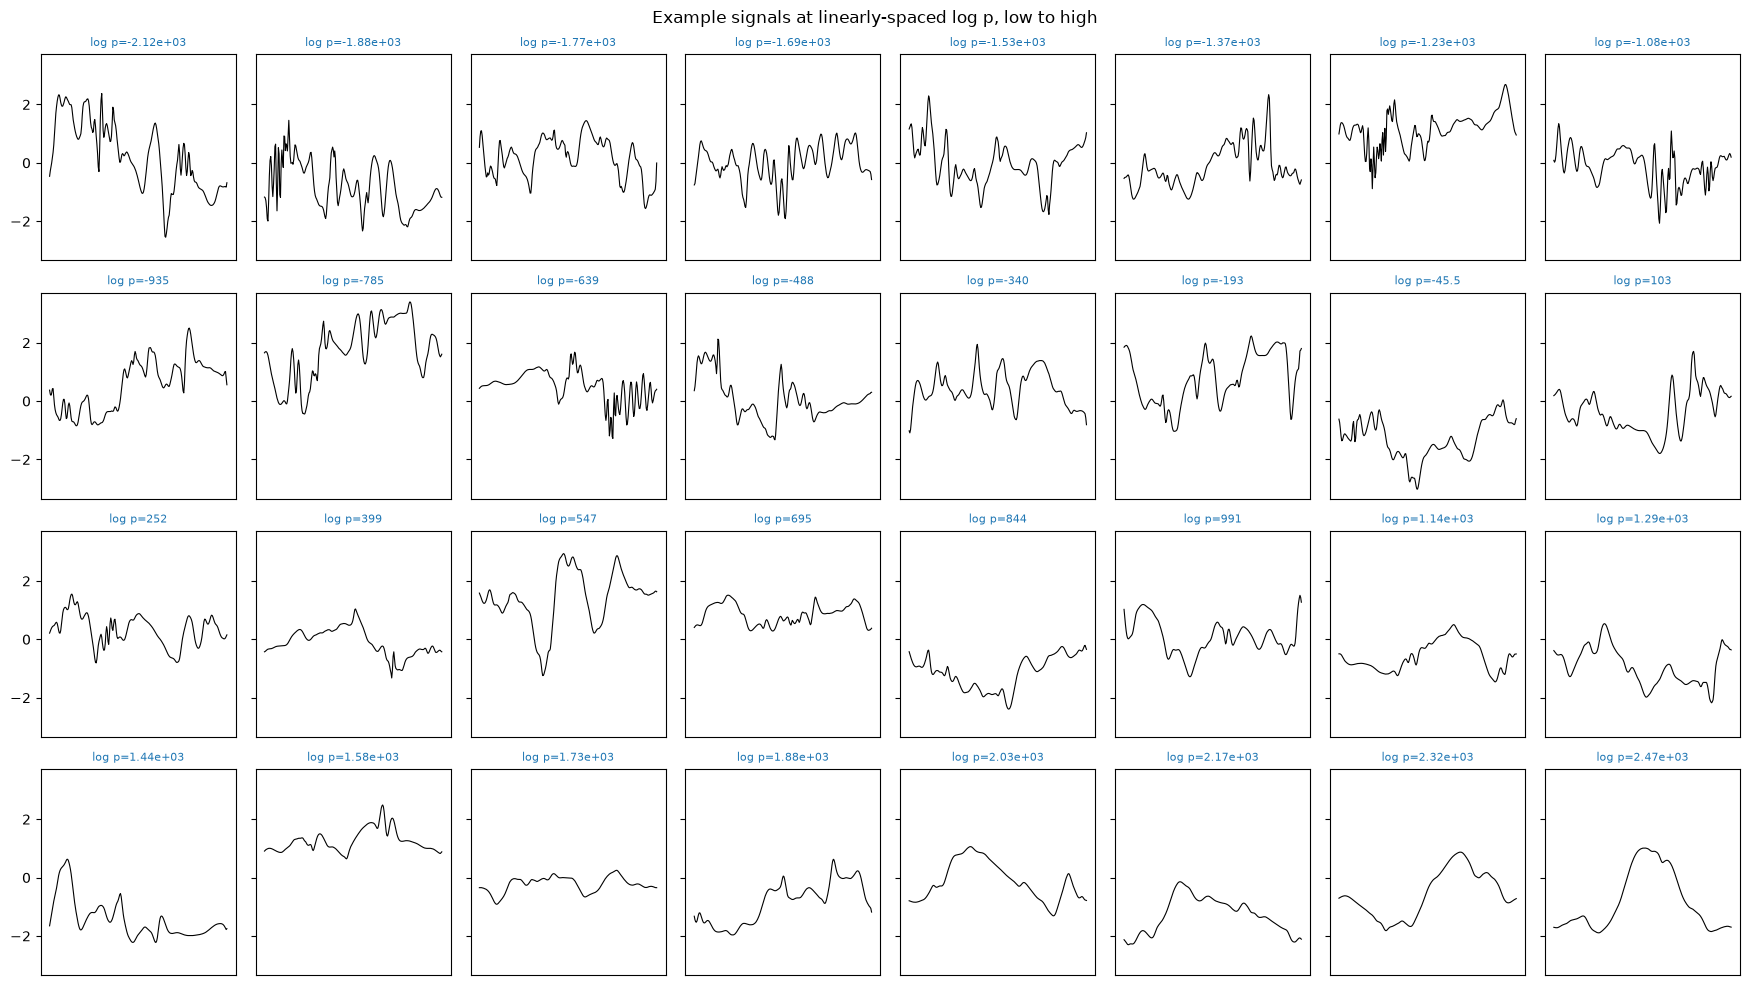

In [78]:
n_examples = 32  # any number; wraps at 8 per row
n_cols = 8
n_rows = math.ceil(n_examples / n_cols)

logp_targets = np.linspace(total_log_p_unnorm.min(), total_log_p_unnorm.max(), n_examples)
example_idx = [int(np.argmin(np.abs(total_log_p_unnorm - t))) for t in logp_targets]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 2.5 * n_rows), sharey=True, squeeze=False)
for i, idx in enumerate(example_idx):
    ax = axes[i // n_cols][i % n_cols]
    ax.plot(x1[idx, 0].cpu().numpy(), lw=0.8, color='black')
    label_color = category_colors['rare'] if idx in set(idx_rare) else category_colors['typical']
    ax.set_title(f'log p={total_log_p_unnorm[idx]:.3g}', fontsize=8, color=label_color)
    ax.set_xticks([])
for j in range(n_examples, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis('off')
fig.suptitle('Example signals at linearly-spaced log p, low to high')
fig.tight_layout()
plt.show()

## Fisher vs Dirichlet, typical vs rare

$\Sigma$/$G$ estimated separately on each category's own subset of `x1` -- does the model's covariance/gradient structure differ for rare events? `rare` has far fewer samples than `typical`, so also check $\Sigma$'s convergence there specifically (it needs higher-order moments and is the more likely one to be under-converged on a small n).

In [74]:
def sample_covariance(phi):
    return np.cov(phi, rowvar=False, ddof=1)

Sigma_by_category, G_by_category = {}, {}
for category, idx in category_indices.items():
    x_cat = x1[idx]
    phi_cat = compute_phi_X(potentials_ref, x_cat).detach().cpu().numpy()
    J_cat = compute_phi_grad_X(potentials_ref, x_cat)
    Sigma_by_category[category] = sample_covariance(phi_cat)
    G_by_category[category] = (torch.einsum('ndt,net->de', J_cat, J_cat) / J_cat.shape[0]).cpu().numpy()

cond_rows = []
for name, (a, b) in family_ranges.items():
    row = {'family': name, 'dim': b - a}
    for category in category_indices:
        row[f'cond(Sigma)_{category}'] = np.linalg.cond(Sigma_by_category[category][a:b, a:b])
        row[f'cond(G)_{category}'] = np.linalg.cond(G_by_category[category][a:b, a:b])
    cond_rows.append(row)
display(pd.DataFrame(cond_rows))

,family,dim,cond(Sigma)_typical,cond(G)_typical,cond(Sigma)_rare,cond(G)_rare
0,L_6,9,8.921951e+12,1.740676e+10,5.444570e+10,2.836088e+07
1,L_6_psi,25,1.211004e+37,4.633080e+27,3.869429e+31,6.807935e+26
2,L_2_lowpass,1,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
3,Scalar_psi_gaussianK,70,4.352983e+27,4.135571e+24,1.192505e+34,1.178277e+25
4,Scalar_morlet_gaussianK,27,6.081356e+08,1.058049e+02,4.453377e+18,2.815799e+02
5,Scattering_Fourth_Order_Mod2_Real_Q1,84,1.508352e+11,3.027063e+08,2.416110e+21,5.101062e+06
6,Scattering_Fourth_Order_Mod2_Imag_Q1,56,6.634899e+09,5.022495e+06,4.753604e+19,5.075005e+05


**Caveat:** the `rare` columns above (n=25) are not meaningful for families with more coefficients than that -- e.g. `Scattering_Fourth_Order_Mod2_Real_Q1` has dim=84 > 25, so `Sigma`/`G` on the rare subset are rank-deficient and their condition numbers are not interpretable. Only the `typical` columns should be read here.

**Note:** the cell below cannot actually show convergence -- `n_grid` only spans 20 to `len(idx_rare)=25`, too narrow a range to see a trend. Kept as-is (not deleted) since it still reports the raw values at each `n`, just not a convergence curve.

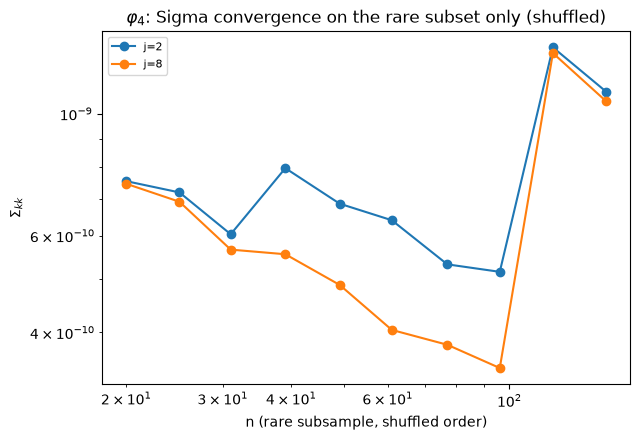

In [58]:
pot_re = potentials_ref[REAL_KEY]
j_arr, s1_arr, s2_arr = decode_mod2_stq(pot_re, verbose=False)
a_re4, b_re4 = family_ranges[REAL_KEY]
j_vals_arr = np.array(sorted(set(j_arr.tolist())))
track_idx = {
    f'j={j_vals_arr.min()}': int(np.where(j_arr == j_vals_arr.min())[0][0]),
    f'j={j_vals_arr.max()}': int(np.where(j_arr == j_vals_arr.max())[0][0]),
}

# Shuffle before taking growing prefixes -- idx_rare is in dataset order, so an
# unshuffled prefix just reveals WHERE a high-leverage outlier sits, not whether the
# estimate is actually converging. A fixed seed keeps this reproducible.
rng = np.random.default_rng(0)
idx_rare_shuffled = rng.permutation(idx_rare)
rare_x1 = x1[idx_rare_shuffled]

phi4_rare = compute_phi_X(potentials_ref, rare_x1).detach().cpu().numpy()[:, a_re4:b_re4]
n_grid = np.unique(np.round(np.geomspace(20, len(idx_rare), 10)).astype(int))
Sigma_conv = {name: [] for name in track_idx}
for n in n_grid:
    cov_n = np.cov(phi4_rare[:n], rowvar=False, ddof=1)
    for name, idx_k in track_idx.items():
        Sigma_conv[name].append(cov_n[idx_k, idx_k])

%matplotlib inline
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for name in track_idx:
    ax.plot(n_grid, Sigma_conv[name], marker='o', label=name)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('n (rare subsample, shuffled order)'); ax.set_ylabel(r'$\Sigma_{kk}$')
ax.set_title(r'$\varphi_4$: Sigma convergence on the rare subset only (shuffled)')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 1. Per-seed family contributions with error bars

For each seed, `C[F][s, i] = theta_s,F . phi_F(x_i)` (log p contribution, nats). `D[s,F] = mean(C over rare) - mean(C over typical)`. Table: mean/std of D across the 43 seeds, plus a bootstrap SE over the 25 rare signals (1000 resamples, using the seed-averaged C).

sum(family D) - TOTAL D = 3.052e-04  (should be ~0)


,family,mean_D,std_D_across_seeds,bootstrap_SE_rare
0,L_6,-34.347263,5.583200,8.299357
1,L_6_psi,-9.409779,4.973411,4.910482
2,L_2_lowpass,0.540383,0.031500,1.716858
3,Scalar_psi_gaussianK,-635.590698,5.352113,40.148747
4,Scalar_morlet_gaussianK,-331.146759,4.930728,16.755224
5,Scattering_Fourth_Order_Mod2_Real_Q1,34.661549,10.206434,23.714262
6,Scattering_Fourth_Order_Mod2_Imag_Q1,2.094345,2.245894,1.246469
7,TOTAL,-973.198486,5.977035,58.448288


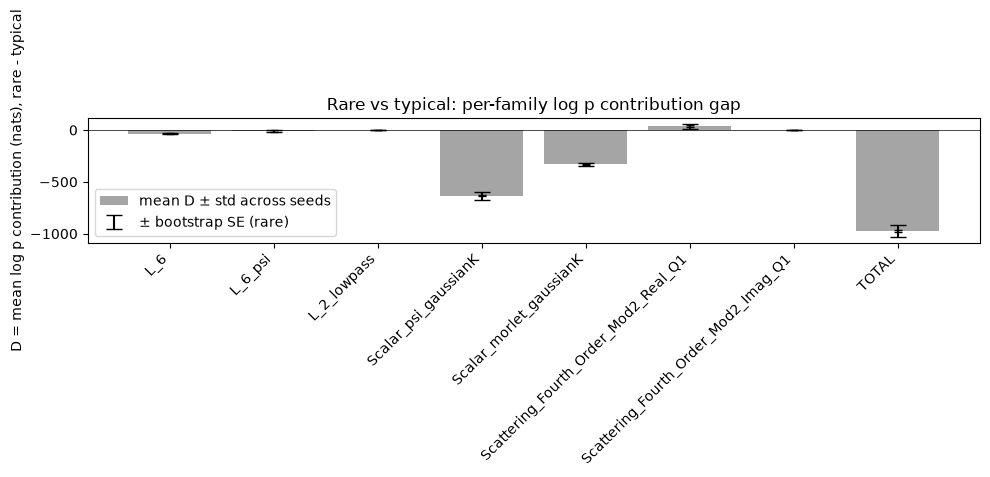

In [55]:
reg_all_np = reg_all.numpy()  # (43, 272)
family_names_all = list(ranges_with_total.keys())  # 7 families + TOTAL

# C[F]: (n_seeds, n1) -- per-seed, per-signal log p contribution (nats) of family F
C = {F: reg_all_np[:, a:b] @ phi_X[:, a:b].T for F, (a, b) in ranges_with_total.items()}

D = np.stack([C[F][:, idx_rare].mean(axis=1) - C[F][:, idx_typical].mean(axis=1)
              for F in family_names_all], axis=1)  # (n_seeds, n_families+1)
D_mean = D.mean(axis=0)
D_std = D.std(axis=0, ddof=1)

# sanity check: C[TOTAL] = sum_F C[F] exactly (linear), so D[TOTAL] should equal sum_F D[F]
total_i = family_names_all.index('TOTAL')
family_sum = sum(D_mean[i] for i, F in enumerate(family_names_all) if F != 'TOTAL')
print(f"sum(family D) - TOTAL D = {family_sum - D_mean[total_i]:.3e}  (should be ~0)")

# Bootstrap SE over the 25 rare signals only (typical, n=4975, held fixed), using the
# seed-averaged C -- this is exactly family_energy / total_log_p_unnorm, already computed above.
C_bar = {**family_energy, 'TOTAL': total_log_p_unnorm}
rng = np.random.default_rng(0)  # assumption: fixed seed for reproducibility, not specified
n_boot = 1000
idx_rare_arr = np.array(idx_rare)
typical_mean = {F: C_bar[F][idx_typical].mean() for F in family_names_all}
boot_D = np.empty((n_boot, len(family_names_all)))
for b in range(n_boot):
    resample = rng.choice(idx_rare_arr, size=len(idx_rare_arr), replace=True)
    boot_D[b] = [C_bar[F][resample].mean() - typical_mean[F] for F in family_names_all]
boot_se = boot_D.std(axis=0, ddof=1)

table1 = pd.DataFrame({'family': family_names_all, 'mean_D': D_mean,
                        'std_D_across_seeds': D_std, 'bootstrap_SE_rare': boot_se})
display(table1)

fig, ax = plt.subplots(figsize=(10, 4))
xpos = np.arange(len(family_names_all))
ax.bar(xpos, D_mean, yerr=D_std, capsize=3, color='tab:gray', alpha=0.7,
       label='mean D ± std across seeds')
ax.errorbar(xpos, D_mean, yerr=boot_se, fmt='none', ecolor='black', capsize=6, lw=1.5,
            label='± bootstrap SE (rare)')
ax.axhline(0, color='black', lw=0.5)
ax.set_xticks(xpos); ax.set_xticklabels(family_names_all, rotation=45, ha='right')
ax.set_ylabel('D = mean log p contribution (nats), rare - typical')
ax.set_title('Rare vs typical: per-family log p contribution gap')
ax.legend()
fig.tight_layout()
plt.show()

## 2. Robustness to the rare/typical threshold

Repeat the seed-mean D (no bootstrap) for `percentile` in {95, 99, 99.5} in `extract_rare_typical`.

In [59]:
percentiles = [95, 99, 99.5]
table2 = {}
for p in percentiles:
    idx_typ_p, idx_rare_p, _ = extract_rare_typical(Data[:n1], criterion='percentile', percentile=p)
    table2[f'p{p}'] = [C[F][:, idx_rare_p].mean(axis=1).mean() - C[F][:, idx_typ_p].mean(axis=1).mean()
                        for F in family_names_all]
table2_df = pd.DataFrame(table2, index=family_names_all)
display(table2_df)

,p95,p99,p99.5
L_6,-23.337280,-81.609840,-134.256042
L_6_psi,-5.583845,-24.437656,-35.359150
L_2_lowpass,0.506426,1.288838,3.431560
Scalar_psi_gaussianK,-660.164429,-646.930298,-624.273926
Scalar_morlet_gaussianK,-315.205719,-360.799713,-340.819458
Scattering_Fourth_Order_Mod2_Real_Q1,7.775888,153.962067,282.345886
Scattering_Fourth_Order_Mod2_Imag_Q1,1.402821,4.957232,4.308362
TOTAL,-994.606445,-953.569763,-844.622986


## 3. Continuous version (no split)

Extremeness `e_i = max_t |acceleration|` per signal. Per family: centered log p contribution vs `e_i` (log x-axis), 99.5th-percentile rare points highlighted. Table of Spearman rank correlation per family.

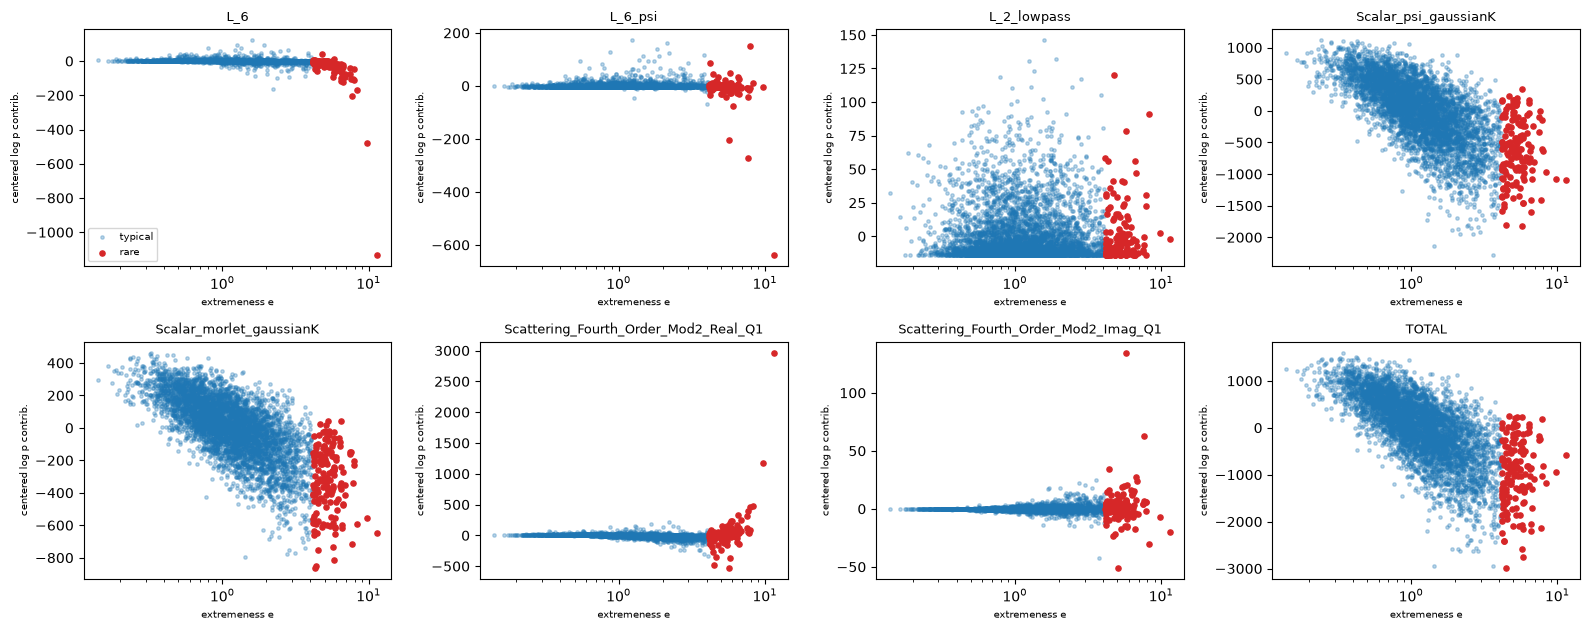

,family,spearman_rho
0,L_6,-0.459958
1,L_6_psi,-0.027490
2,L_2_lowpass,-0.006313
3,Scalar_psi_gaussianK,-0.705358
4,Scalar_morlet_gaussianK,-0.708468
5,Scattering_Fourth_Order_Mod2_Real_Q1,-0.549664
6,Scattering_Fourth_Order_Mod2_Imag_Q1,0.053093
7,TOTAL,-0.723459


In [60]:
accel = compute_acceleration(Data[:n1])  # (n1, 1, 255)
e = accel.abs().amax(dim=(1, 2)).cpu().numpy()  # (n1,) extremeness

n_cols = 4
n_rows = math.ceil(len(family_names_all) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.2 * n_rows), squeeze=False)
mask_rare = np.zeros(n1, dtype=bool)
mask_rare[idx_rare] = True

spearman_rows = []
for i, F in enumerate(family_names_all):
    ax = axes[i // n_cols][i % n_cols]
    y = C_bar[F] - C_bar[F].mean()
    ax.scatter(e[~mask_rare], y[~mask_rare], s=6, alpha=0.3, color=category_colors['typical'], label='typical')
    ax.scatter(e[mask_rare], y[mask_rare], s=14, color=category_colors['rare'], label='rare')
    ax.set_xscale('log')
    ax.set_title(F, fontsize=9)
    ax.set_xlabel('extremeness e', fontsize=7)
    ax.set_ylabel('centered log p contrib.', fontsize=7)
    # Spearman = Pearson correlation of ranks (avoids a scipy import)
    rho = np.corrcoef(pd.Series(e).rank(), pd.Series(C_bar[F]).rank())[0, 1]
    spearman_rows.append({'family': F, 'spearman_rho': rho})
axes[0][0].legend(fontsize=7)
for j in range(len(family_names_all), n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis('off')
fig.tight_layout()
plt.show()

display(pd.DataFrame(spearman_rows))

## 4. Compensation between families

Correlation matrix of the 7 families' log p contributions across all n1 signals, plus how much of TOTAL's variance the cross-family covariances cancel.

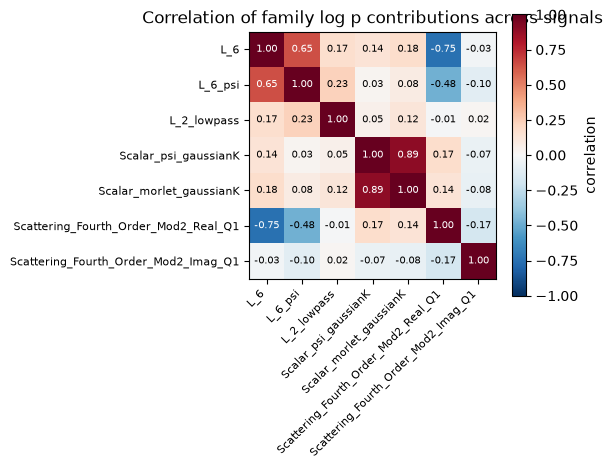

Var(TOTAL) = 5.038e+05
sum(Var(family)) = 3.069e+05
-> cross-family covariance cancels -1.97e+05 (-64.2% of the family-variance sum)


In [61]:
fam_only = list(family_ranges.keys())
C_mat = np.stack([C_bar[F] for F in fam_only], axis=0)  # (7, n1)
corr = np.corrcoef(C_mat)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(fam_only))); ax.set_xticklabels(fam_only, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(fam_only))); ax.set_yticklabels(fam_only, fontsize=8)
for i in range(len(fam_only)):
    for j in range(len(fam_only)):
        ax.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr[i, j]) > 0.5 else 'black')
fig.colorbar(im, ax=ax, label='correlation')
ax.set_title('Correlation of family log p contributions across signals')
fig.tight_layout()
plt.show()

var_total = C_bar['TOTAL'].var(ddof=1)
var_sum_families = sum(C_bar[F].var(ddof=1) for F in fam_only)
print(f"Var(TOTAL) = {var_total:.4g}")
print(f"sum(Var(family)) = {var_sum_families:.4g}")
print(f"-> cross-family covariance cancels {var_sum_families - var_total:.4g} "
      f"({100 * (var_sum_families - var_total) / var_sum_families:.1f}% of the family-variance sum)")

## 5. Model samples

First check what's actually on disk under `saved_results/samples/` for each seed. If none are found, stop here -- the rest of this section assumes at least one exists.

In [62]:
sample_info = []
for key in seed_keys:
    cfg = config_by_seed[key]
    p = root / "saved_results" / "samples" / cfg
    p_pt = p.with_name(p.name + ".pt")
    path = p_pt if p_pt.exists() else (p if p.exists() else None)
    row = {'seed': key, 'found': path is not None}
    if path is not None:
        row['file'] = path.name
        row['x_t_shape'] = tuple(torch.load(path, map_location='cpu').shape)
    sample_info.append(row)

sample_df = pd.DataFrame(sample_info)
display(sample_df)
n_found = int(sample_df['found'].sum())
print(f"{n_found}/{len(seed_keys)} seeds have a samples/ file on disk.")

/tmp/ipykernel_2408845/3744334705.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  row['x_t_shape'] = tuple(torch.load(path, map_location='cpu').shape)


,seed,found,file,x_t_shape
0,seed300,True,turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1...,"(5000, 1, 256)"
1,seed301,True,turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1...,"(5000, 1, 256)"
2,seed302,True,turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1...,"(5000, 1, 256)"
3,seed303,True,turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1...,"(5000, 1, 256)"
4,seed304,True,turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1...,"(5000, 1, 256)"
5,seed305,True,turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1...,"(5000, 1, 256)"
6,seed306,True,turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1...,"(5000, 1, 256)"
7,seed307,True,turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1...,"(5000, 1, 256)"
8,seed308,True,turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1...,"(5000, 1, 256)"
9,seed309,True,turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1...,"(5000, 1, 256)"


43/43 seeds have a samples/ file on disk.


Load each seed's final-time sample, compute phi with that seed's own fitted potentials, and check whether samples need `normalize()` to match `x1`'s convention (checked once, assumed the same for every seed). GPU memory: samples move to `device` only for the `compute_phi_X` call, then are freed immediately.

In [63]:
# Reuses potentials_by_seed[key] -- each seed's OWN fitted potentials, already cached
# during the seed-loading loop above -- so each seed's theta pairs with phi(x) from
# that SAME seed's fitted potentials (as fit), not the shared potentials_ref.
model_norm_checked = False
needs_norm = None
C_model = {}   # seed_key -> {family: (n_model,) array}, includes 'TOTAL'
e_model = {}   # seed_key -> (n_model,) extremeness, same lag-1/max|.| definition, at x_t's own stage

for key in seed_keys:
    cfg = config_by_seed[key]
    p = root / "saved_results" / "samples" / cfg
    p_pt = p.with_name(p.name + ".pt")
    path = p_pt if p_pt.exists() else p
    x_t = torch.load(path, map_location='cpu')
    x_final = x_t[-1]   # assumption: leading axis is sampling time, as for theta_t/Theta_reg

    if not model_norm_checked:
        m, s = x_final.mean().item(), x_final.std().item()
        needs_norm = not (abs(m) < 0.05 and abs(s - 1) < 0.05)
        print(f"model samples: mean={m:.4g} std={s:.4g} -> "
              f"{'applying' if needs_norm else 'skipping'} normalize() (checked on {key} only)")
        model_norm_checked = True

    x_model = (normalize(x_final) if needs_norm else x_final).to(device)
    phi_model = compute_phi_X(potentials_by_seed[key], x_model).detach().cpu().numpy()
    del x_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    s_idx = seed_keys.index(key)
    c_this = {F: phi_model[:, a:b] @ reg_all_np[s_idx, a:b] for F, (a, b) in family_ranges.items()}
    c_this['TOTAL'] = sum(c_this.values())
    C_model[key] = c_this

    accel_model = x_final[..., 1:] - x_final[..., :-1]
    e_model[key] = accel_model.abs().amax(dim=tuple(range(1, accel_model.ndim))).numpy()

print(f"Computed model-sample phi/log-p contributions for {len(C_model)} seeds.")

model samples: mean=-0.3971 std=0.7509 -> applying normalize() (checked on seed300 only)
Computed model-sample phi/log-p contributions for 43 seeds.


/tmp/ipykernel_2408845/797333902.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x_t = torch.load(path, map_location='cpu')


### 5a. Data vs model: TOTAL log p contribution and per-family std

Same-seed theta on data (from step 1's `C`) vs on that seed's model samples, pooled across seeds.

L_6                                           data std=     20.99   model std=     33.91
L_6_psi                                       data std=     15.58   model std=     53.18
L_2_lowpass                                   data std=     20.22   model std=  0.007417
Scalar_psi_gaussianK                          data std=     514.4   model std=     287.1
Scalar_morlet_gaussianK                       data std=     195.2   model std=     123.9
Scattering_Fourth_Order_Mod2_Real_Q1          data std=     56.44   model std=     134.6
Scattering_Fourth_Order_Mod2_Imag_Q1          data std=     6.629   model std=     17.06


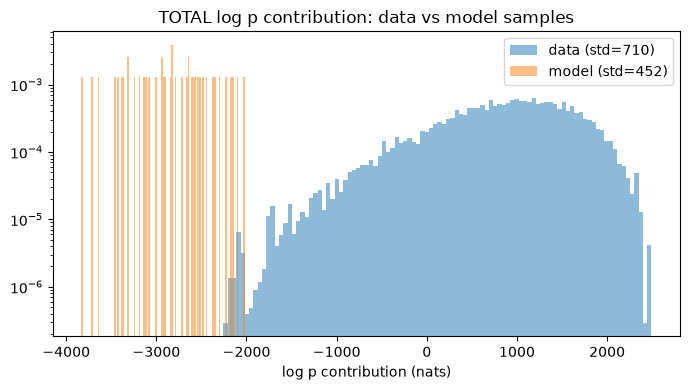

In [64]:
for F in family_names_all:
    data_vals = np.concatenate([C[F][seed_keys.index(k)] for k in seed_keys])
    model_vals = np.concatenate([C_model[k][F] for k in seed_keys])
    if F == 'TOTAL':
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.hist(data_vals, bins=100, density=True, alpha=0.5, color='tab:blue',
                label=f'data (std={data_vals.std():.3g})')
        ax.hist(model_vals, bins=100, density=True, alpha=0.5, color='tab:orange',
                label=f'model (std={model_vals.std():.3g})')
        ax.set_yscale('log'); ax.legend()
        ax.set_xlabel('log p contribution (nats)')
        ax.set_title('TOTAL log p contribution: data vs model samples')
        fig.tight_layout(); plt.show()
    else:
        print(f"{F:45s} data std={data_vals.std():10.4g}   model std={model_vals.std():10.4g}")

### 5b. Rare fraction: model vs data, same cutoff

Apply the data 99.5th-percentile cutoff (`info_split['cutoff']`) to `max|lag-1 increment|` of the model samples.

In [65]:
cutoff995 = info_split['cutoff']
model_rare_frac = np.array([(e_model[k] > cutoff995).mean() for k in seed_keys])
data_rare_frac = len(idx_rare) / n1

print(f"data rare fraction (99.5th pctile, by construction) = {data_rare_frac:.4f}")
print(f"model rare fraction (same cutoff={cutoff995:.4g}): "
      f"mean={model_rare_frac.mean():.4f}, std={model_rare_frac.std(ddof=1):.4f} across {len(seed_keys)} seeds")
print("CAVEAT: cutoff995 was calibrated on raw Data[:n1] (pre-wavelet, per this notebook's own "
      "split-cell note); x_t/model samples live in x1's stage (post-wavelet, the SDE's fitting "
      "domain) -- a different signal stage. This assumes the wavelet transform doesn't change the "
      "increment scale much; not verified here.")

n_model_rare_total = int(sum((e_model[k] > cutoff995).sum() for k in seed_keys))
if n_model_rare_total < 20:
    _, _, info99 = extract_rare_typical(Data[:n1], criterion='percentile', percentile=99)
    cutoff99 = info99['cutoff']
    model_rare_frac_99 = np.array([(e_model[k] > cutoff99).mean() for k in seed_keys])
    print(f"\nOnly {n_model_rare_total} model-rare samples total (<20) -> also using the data "
          f"99th-percentile cutoff ({cutoff99:.4g}): mean model rare fraction = "
          f"{model_rare_frac_99.mean():.4f}")

data rare fraction (99.5th pctile, by construction) = 0.0300
model rare fraction (same cutoff=4.154): mean=0.0000, std=0.0000 across 43 seeds
CAVEAT: cutoff995 was calibrated on raw Data[:n1] (pre-wavelet, per this notebook's own split-cell note); x_t/model samples live in x1's stage (post-wavelet, the SDE's fitting domain) -- a different signal stage. This assumes the wavelet transform doesn't change the increment scale much; not verified here.

Only 0 model-rare samples total (<20) -> also using the data 99th-percentile cutoff (5.587): mean model rare fraction = 0.0000


### 5c. Model-side sensitivity vs data-side

`S_F = mean(C_F | rare) - mean(C_F | all)` (baseline is ALL samples here, not typical -- different from D in step 1), computed per seed on both model and data, then mean/std over seeds.

In [66]:
rows = []
for F in family_names_all:
    s_model, s_data = [], []
    for i, k in enumerate(seed_keys):
        rare_mask = e_model[k] > cutoff995
        if rare_mask.sum() == 0:
            continue
        s_model.append(C_model[k][F][rare_mask].mean() - C_model[k][F].mean())
        s_data.append(C[F][i][idx_rare].mean() - C[F][i].mean())
    rows.append({
        'family': F,
        'model_S_mean': np.mean(s_model), 'model_S_std': np.std(s_model, ddof=1),
        'data_S_mean': np.mean(s_data), 'data_S_std': np.std(s_data, ddof=1),
        'n_seeds_with_model_rare': len(s_model),
    })
display(pd.DataFrame(rows))

/profils_cerea/chiara.zelco/envs/mgd/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/profils_cerea/chiara.zelco/envs/mgd/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/profils_cerea/chiara.zelco/envs/mgd/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/profils_cerea/chiara.zelco/envs/mgd/lib/python3.11/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/profils_cerea/chiara.zelco/envs/mgd/lib/python3.11/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,family,model_S_mean,model_S_std,data_S_mean,data_S_std,n_seeds_with_model_rare
0,L_6,NaN,NaN,NaN,NaN,0
1,L_6_psi,NaN,NaN,NaN,NaN,0
2,L_2_lowpass,NaN,NaN,NaN,NaN,0
3,Scalar_psi_gaussianK,NaN,NaN,NaN,NaN,0
4,Scalar_morlet_gaussianK,NaN,NaN,NaN,NaN,0
5,Scattering_Fourth_Order_Mod2_Real_Q1,NaN,NaN,NaN,NaN,0
6,Scattering_Fourth_Order_Mod2_Imag_Q1,NaN,NaN,NaN,NaN,0
7,TOTAL,NaN,NaN,NaN,NaN,0


## 7. Position-averaging check (inspection only -- not implemented)

Checked `codes/potentials/potentials_1d.py`'s `forward()` for each family in `terms` (via `codes/potentials_builder.py`'s name mapping). All seven reduce over the time axis with `.mean(-1)` applied to a pointwise-in-`u` quantity, so a per-position log p contribution could be defined by skipping that final mean.

| family | position-average? | pointwise quantity (one line) |
|---|---|---|
| L_6 | yes | `\|W_j x(u)\|^6` (`L2p_norm`, p=3, on `filters`) |
| L_6_psi | yes | `\|W_j x(u)\|^6` (`L2p_norm`, p=3, on `filters_Q`) |
| L_2_lowpass | yes | `\|phi*x(u)\|^2` (`L2p_norm`, p=1, low-pass filter only) |
| Scalar_psi_gaussianK | yes | `w_k(u) * \|W_j x(u)\|^{alpha_k}` (soft-windowed GGD-region indicator x power, on `filters_Q`) |
| Scalar_morlet_gaussianK | yes | same form as above, on `filters` |
| Scattering_Fourth_Order_Mod2_Real_Q1 | yes | `Re[(W\|Wx\|^2)_{s1}(u) . conj((W\|Wx\|^2)_{s2}(u))]` |
| Scattering_Fourth_Order_Mod2_Imag_Q1 | yes | `Im[(W\|Wx\|^2)_{s1}(u) . conj((W\|Wx\|^2)_{s2}(u))]` |